# IMU and ecompass characterisation 

## 1. Plot of headings, angular velocity, and heading rate

Processing conduite_normal_0.csv...
  Heading: min=151.03, max=189.60
  Angular Velocity Z: min=-0.76, max=0.23
  Heading Rate: min=-55.23, max=44.38


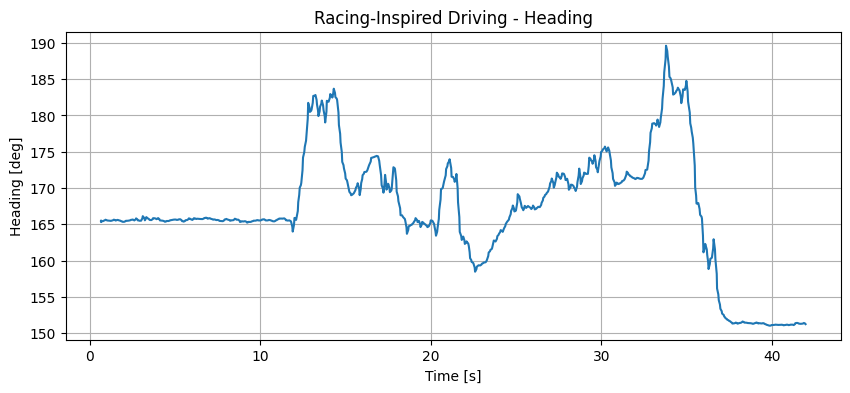

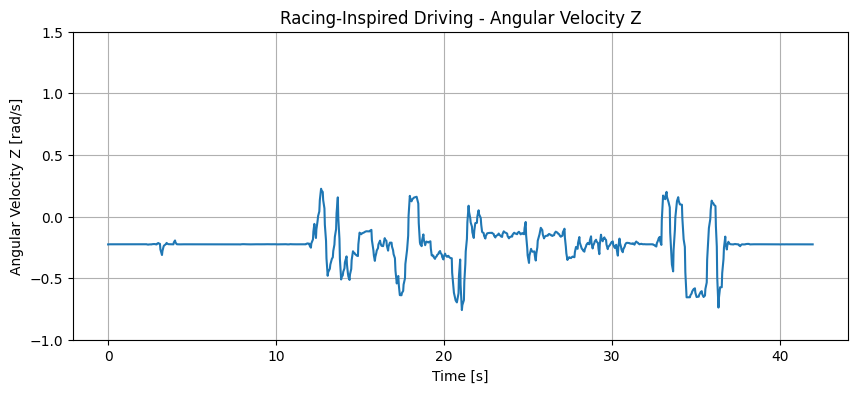

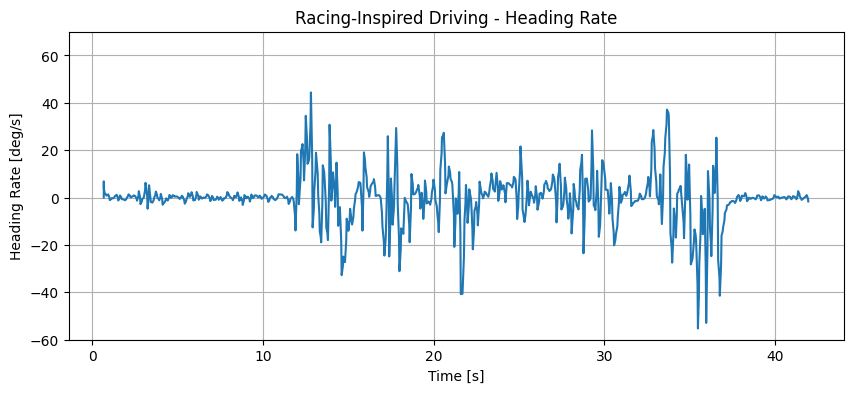

Processing esp_test_2_0.csv...
  Heading: min=193.12, max=207.81
  Angular Velocity Z: min=-0.28, max=1.01
  Heading Rate: min=-29.05, max=33.92
Processing esp_test_0.csv...
  Heading: min=162.47, max=199.27
  Angular Velocity Z: min=-0.25, max=1.30
  Heading Rate: min=-10.90, max=68.55
Processing esp_test_4_0.csv...
  Heading: min=135.58, max=145.35
  Angular Velocity Z: min=-0.25, max=0.83
  Heading Rate: min=-21.60, max=9.62
Processing esp_test_5_0.csv...
  Heading: min=165.45, max=176.30
  Angular Velocity Z: min=-0.80, max=-0.18
  Heading Rate: min=-35.45, max=40.21
Processing esp_test_3_1_0.csv...
  Heading: min=173.57, max=182.26
  Angular Velocity Z: min=-0.97, max=-0.10
  Heading Rate: min=-10.79, max=18.78


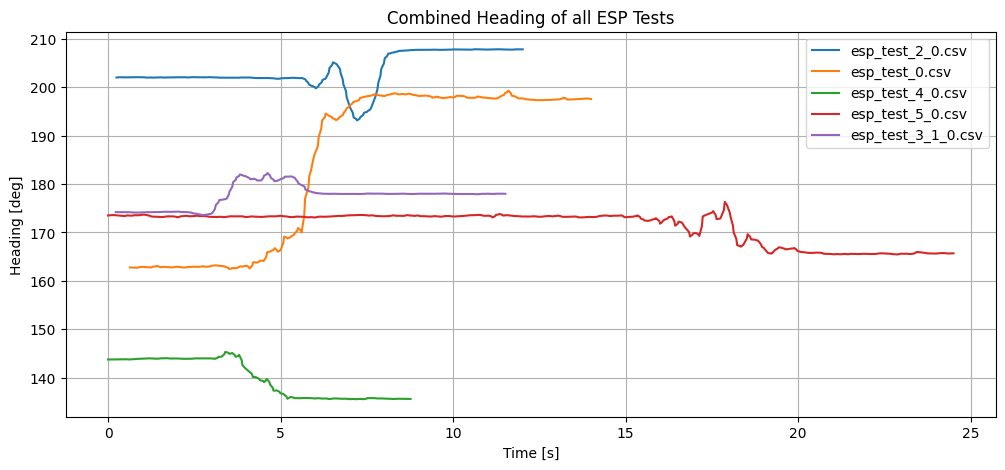

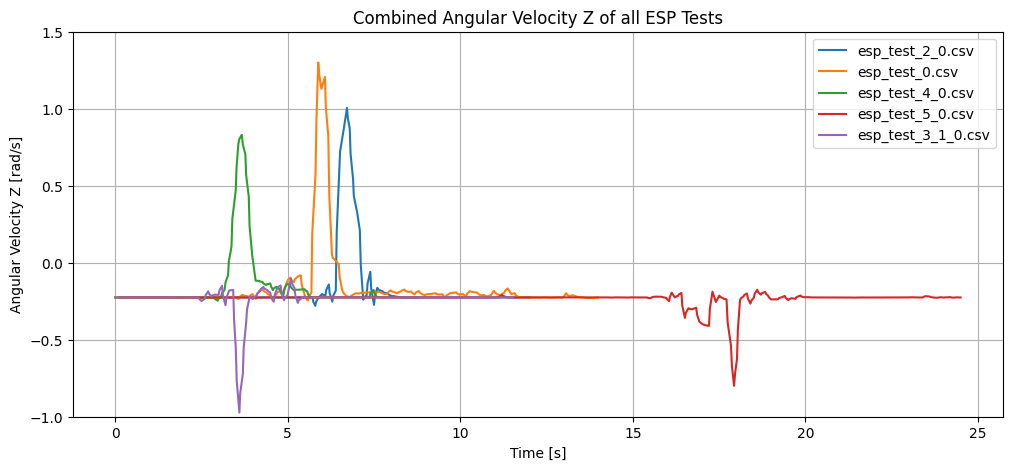

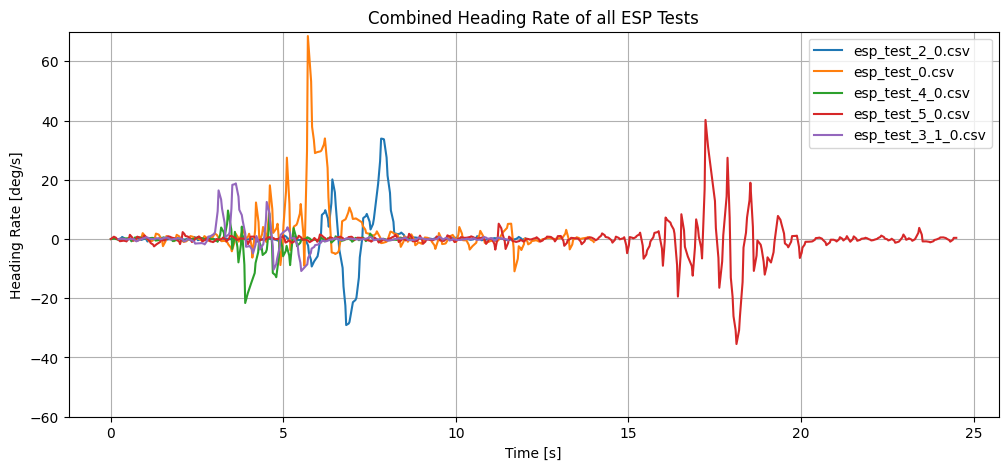

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# CSV Global Variable
csv_folder = "set2/csv"
REF_CSV = "conduite_normal_0.csv"
csv_files = [f for f in os.listdir(csv_folder) if f.endswith(".csv")]

# CSV Graph Parameters
MANUAL_ANG_VEL_MIN = -1
MANUAL_ANG_VEL_MAX = 1.5

MANUAL_RATE_MIN = -60
MANUAL_RATE_MAX = 70

# Containers for combined plots of other CSVs
combined_headings = {}
combined_angular_velocities = {}
combined_heading_rates = {}

for csv_file in csv_files:
    path = os.path.join(csv_folder, csv_file)
    print(f"Processing {csv_file}...")

    df = pd.read_csv(path)
    time = df["time_sec"]

    # Compute heading rate (deg/sec) and filter abnormal values
    last_heading = None
    last_time = None
    heading_rates = []

    for h, t in zip(df["heading"], df["time_sec"]):
        if pd.notna(h) and pd.notna(t):
            if last_heading is None:
                heading_rates.append(0)
            else:
                dt = t - last_time
                rate = (h - last_heading) / dt if dt != 0 else 0
                # To Filter the -1400 from conduite_normal file
                if -100 <= rate <= 100:
                    heading_rates.append(rate)
                else:
                    heading_rates.append(float('nan'))
            last_heading = h
            last_time = t
        else:
            heading_rates.append(float('nan'))

    df["heading_rate_deg_s"] = heading_rates

    # Interpolate to make continuous lines
    df["heading"] = df["heading"].interpolate(method='linear')
    df["angular_velocity_z"] = df["angular_velocity_z"].interpolate(method='linear')
    df["heading_rate_deg_s"] = df["heading_rate_deg_s"].interpolate(method='linear')

    # Print min/max values
    print(f"  Heading: min={df['heading'].min():.2f}, max={df['heading'].max():.2f}")
    print(f"  Angular Velocity Z: min={df['angular_velocity_z'].min():.2f}, max={df['angular_velocity_z'].max():.2f}")
    print(f"  Heading Rate: min={df['heading_rate_deg_s'].min():.2f}, max={df['heading_rate_deg_s'].max():.2f}")

    if csv_file == REF_CSV:
        # Separate line plots for REF_CSV
        plt.figure(figsize=(10,4))
        plt.plot(time, df["heading"], label="heading")
        plt.xlabel("Time [s]")
        plt.ylabel("Heading [deg]")
        plt.title(f"Racing-Inspired Driving - Heading")
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(10,4))
        plt.plot(time, df["angular_velocity_z"], label="angular_velocity_z")
        plt.ylim(MANUAL_ANG_VEL_MIN, MANUAL_ANG_VEL_MAX) 
        plt.xlabel("Time [s]")
        plt.ylabel("Angular Velocity Z [rad/s]")
        plt.title(f"Racing-Inspired Driving - Angular Velocity Z")
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(10,4))
        plt.plot(time, df["heading_rate_deg_s"], label="heading_rate_deg_s")
        plt.ylim(MANUAL_RATE_MIN, MANUAL_RATE_MAX)
        plt.xlabel("Time [s]")
        plt.ylabel("Heading Rate [deg/s]")
        plt.title(f"Racing-Inspired Driving - Heading Rate")
        plt.grid(True)
        plt.show()

    else:
        # Store data for combined plots
        combined_headings[csv_file] = (time, df["heading"])
        combined_angular_velocities[csv_file] = (time, df["angular_velocity_z"])
        combined_heading_rates[csv_file] = (time, df["heading_rate_deg_s"])

# Combined line plots for all other CSVs
if combined_headings:
    plt.figure(figsize=(12,5))
    for file, (time, heading) in combined_headings.items():
        plt.plot(time, heading, label=file)
    plt.xlabel("Time [s]")
    plt.ylabel("Heading [deg]")
    plt.title("Combined Heading of all ESP Tests")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12,5))
    for file, (time, ang_vel) in combined_angular_velocities.items():
        plt.plot(time, ang_vel, label=file)
    plt.ylim(MANUAL_ANG_VEL_MIN, MANUAL_ANG_VEL_MAX) 
    plt.xlabel("Time [s]")
    plt.ylabel("Angular Velocity Z [rad/s]")
    plt.title("Combined Angular Velocity Z of all ESP Tests")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12,5))
    for file, (time, rate) in combined_heading_rates.items():
        plt.plot(time, rate, label=file)
    plt.ylim(MANUAL_RATE_MIN, MANUAL_RATE_MAX)
    plt.xlabel("Time [s]")
    plt.ylabel("Heading Rate [deg/s]")
    plt.title("Combined Heading Rate of all ESP Tests")
    plt.legend()
    plt.grid(True)
    plt.show()


## 2. Individual plot of each test

Processing conduite_normal_0.csv...


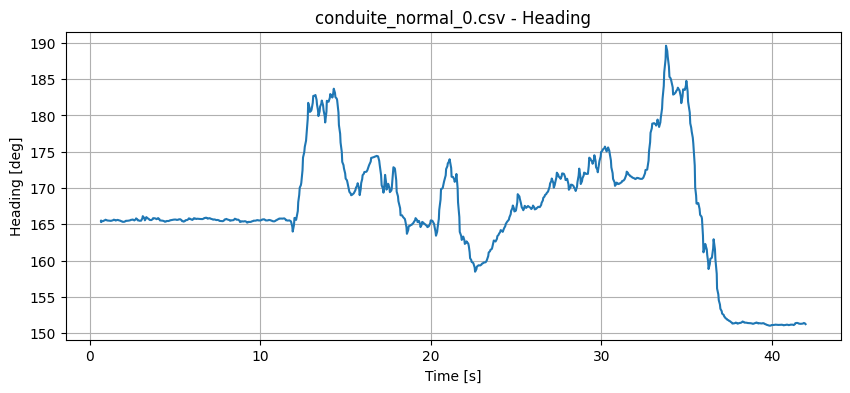

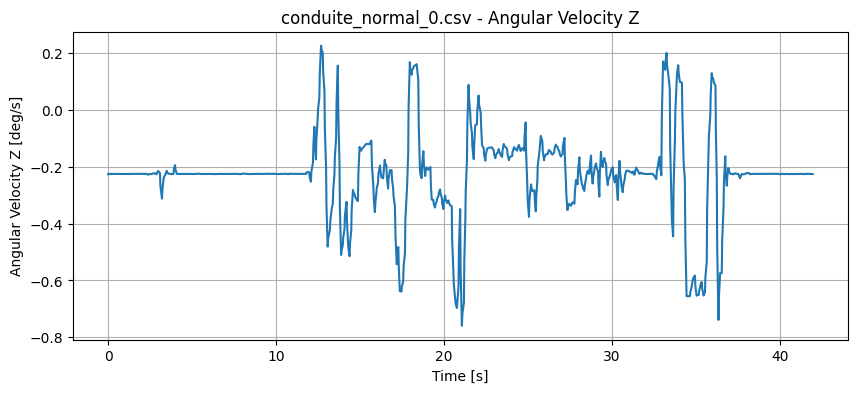

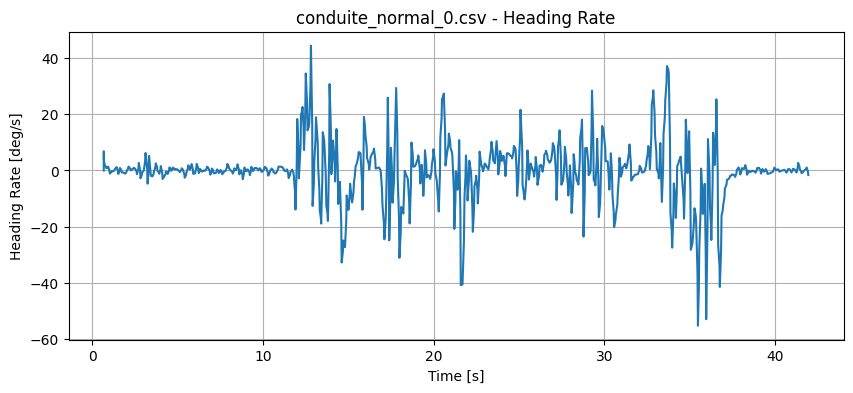

Processing esp_test_2_0.csv...


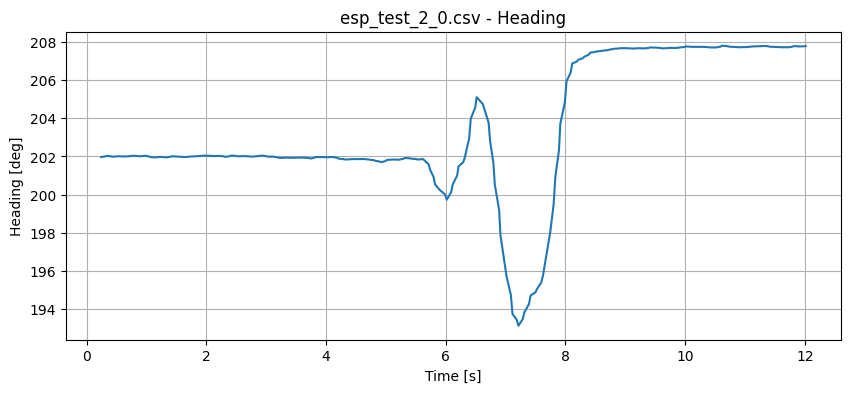

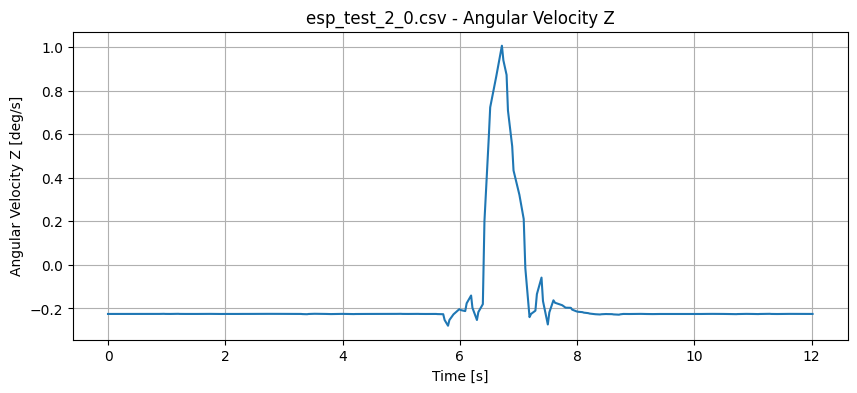

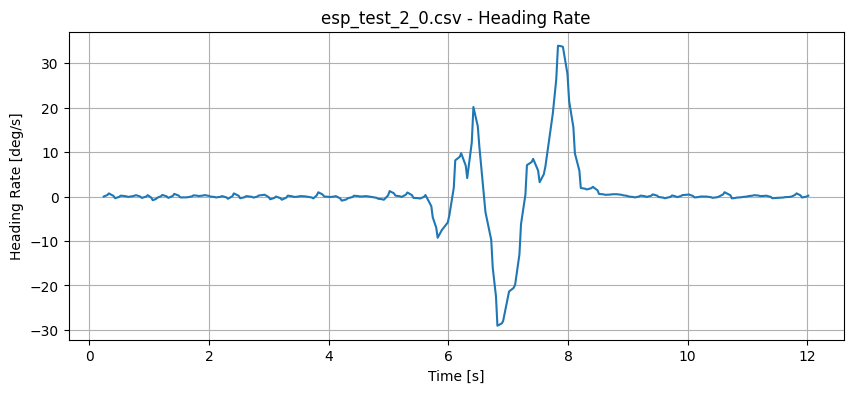

Processing esp_test_0.csv...


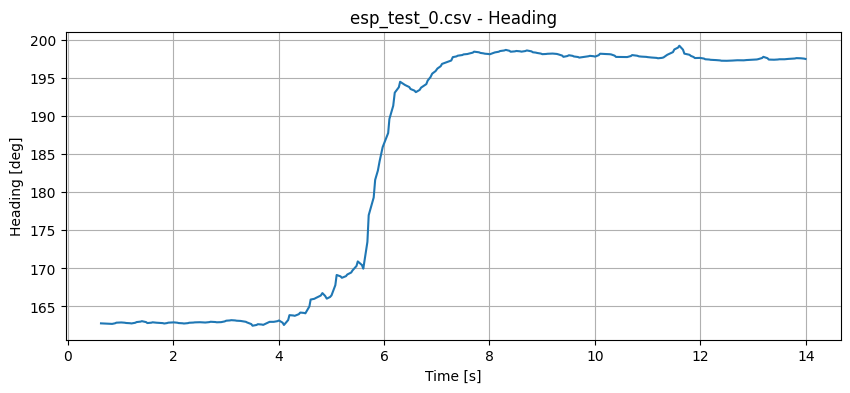

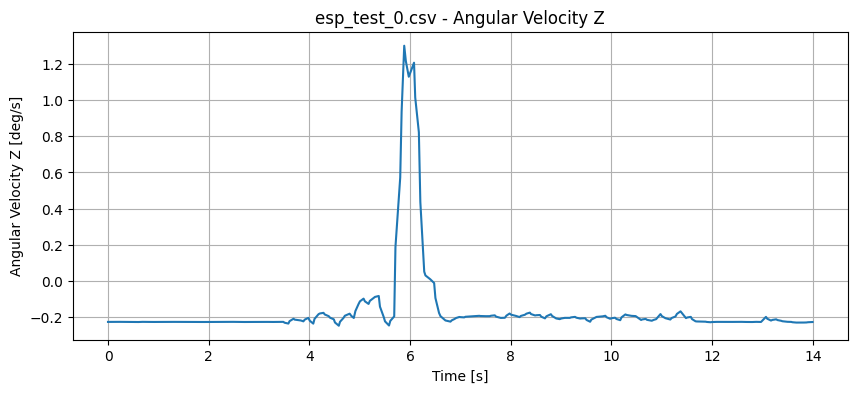

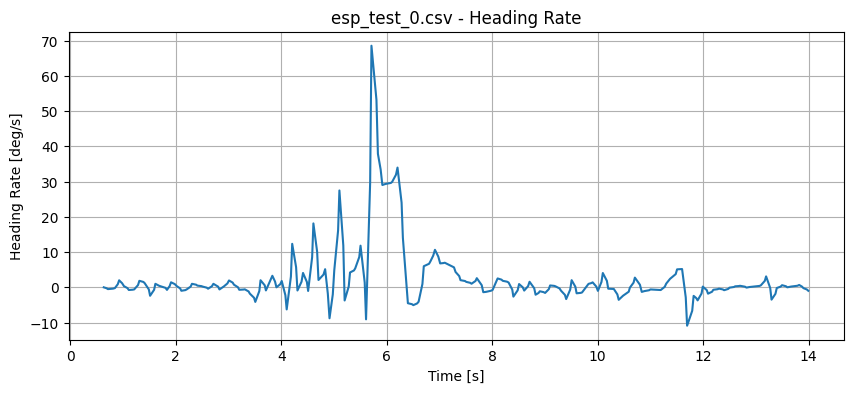

Processing esp_test_4_0.csv...


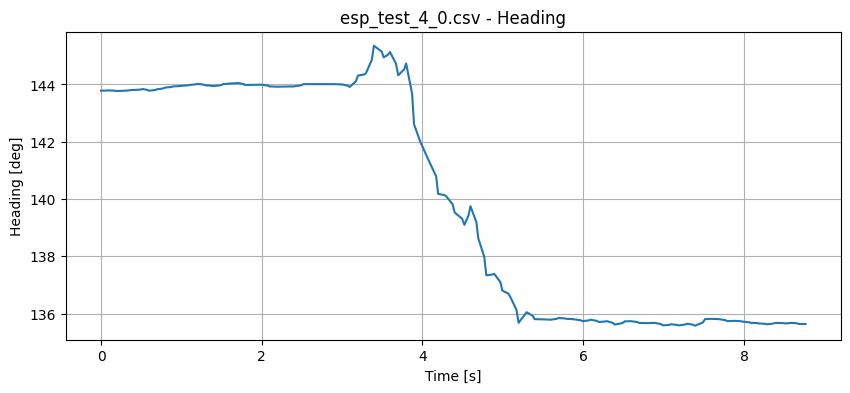

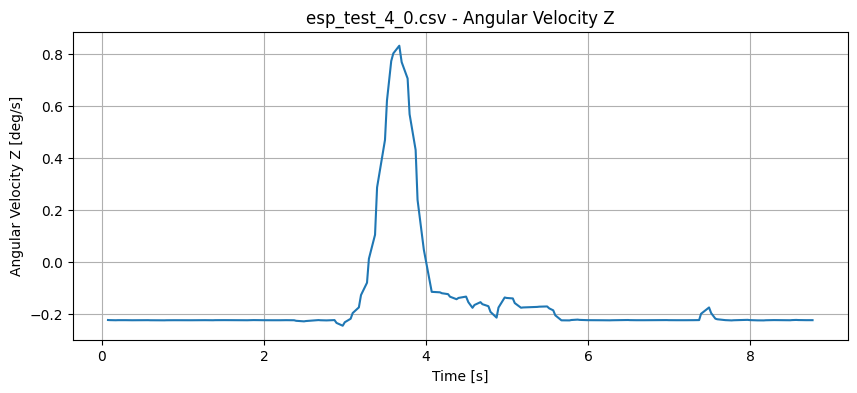

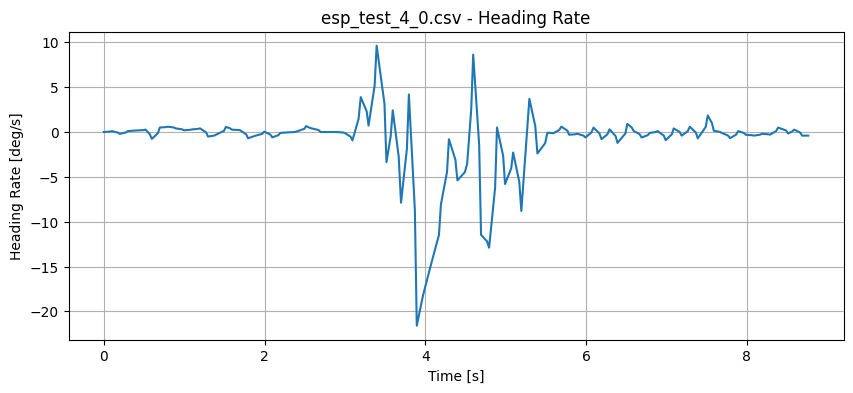

Processing esp_test_5_0.csv...


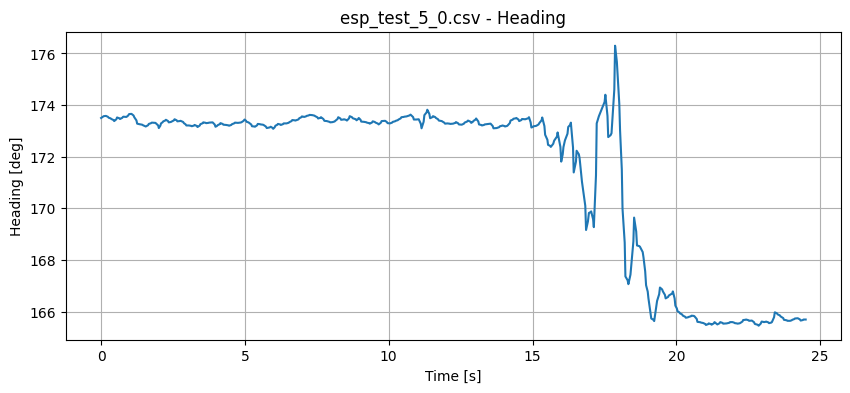

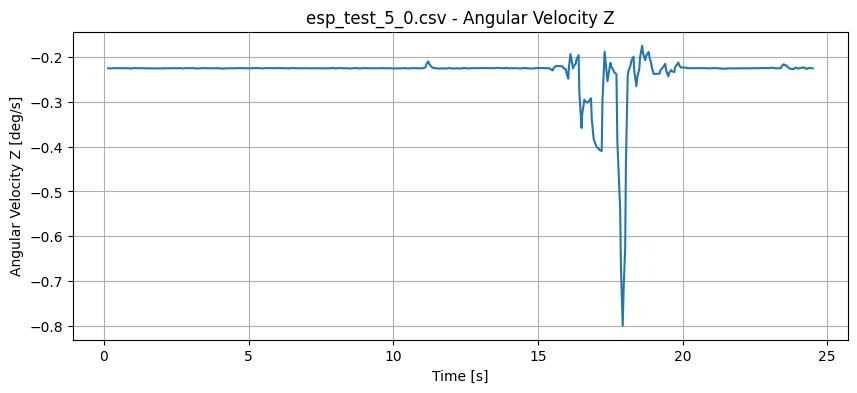

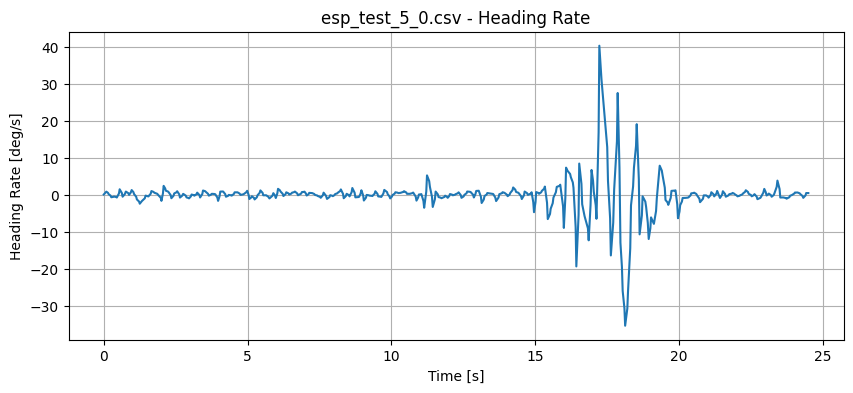

Processing esp_test_3_1_0.csv...


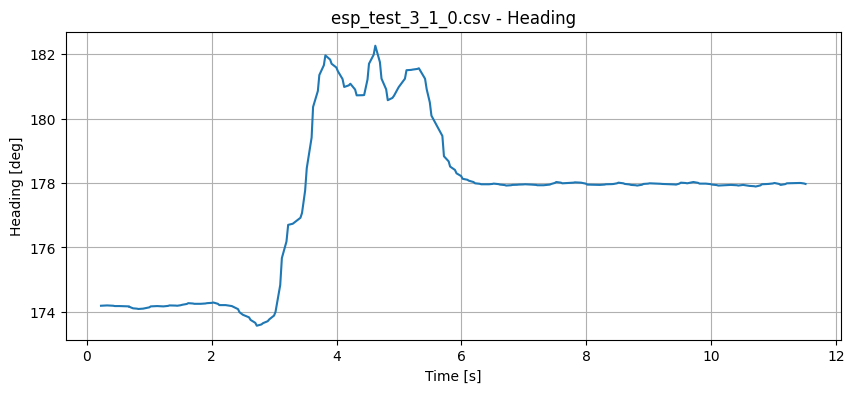

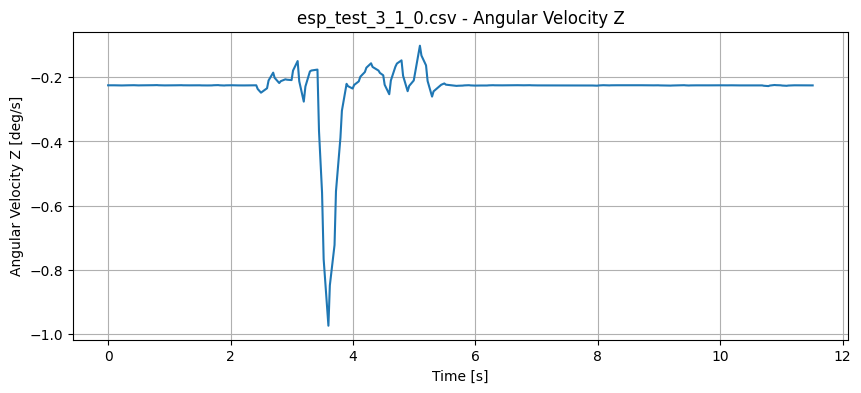

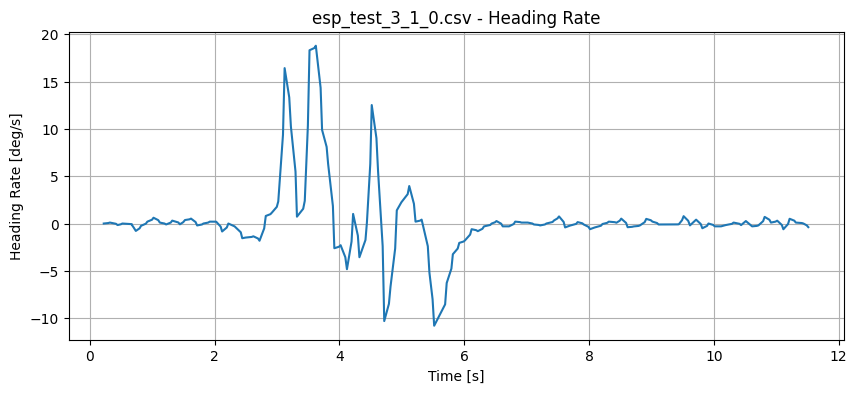

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

POINT_SIZE = 2
csv_folder = "set2/csv"
REF_CSV = "conduite_normal_0.csv"

# List all CSV files
csv_files = [f for f in os.listdir(csv_folder) if f.endswith(".csv")]

def compute_heading_rate(df, min_rate=-100, max_rate=100):
    last_heading = None
    last_time = None
    heading_rates = []

    #Calculate the heading rate without the NaN value
    for h, t in zip(df["heading"], df["time_sec"]):
        if pd.notna(h) and pd.notna(t):
            if last_heading is None:
                heading_rates.append(0)
            else:
                dt = t - last_time
                rate = (h - last_heading) / dt if dt != 0 else 0
                # Filter abnormal values
                if min_rate <= rate <= max_rate:
                    heading_rates.append(rate)
                else:
                    heading_rates.append(float('nan'))
            last_heading = h
            last_time = t
        else:
            heading_rates.append(float('nan'))

    df["heading_rate_deg_s"] = heading_rates
    # Interpolate to make lines continuous
    df["heading"] = df["heading"].interpolate(method='linear')
    df["angular_velocity_z"] = df["angular_velocity_z"].interpolate(method='linear')
    df["heading_rate_deg_s"] = df["heading_rate_deg_s"].interpolate(method='linear')
    return df

for csv_file in csv_files:
    path = os.path.join(csv_folder, csv_file)
    print(f"Processing {csv_file}...")
    df = pd.read_csv(path)
    df = compute_heading_rate(df)
    time = df["time_sec"]

    # Headiing plot
    plt.figure(figsize=(10,4))
    plt.plot(time, df["heading"], label="Heading")
    plt.xlabel("Time [s]")
    plt.ylabel("Heading [deg]")
    plt.title(f"{csv_file} - Heading")
    plt.grid(True)
    plt.show()

    # Angular velocity plot
    plt.figure(figsize=(10,4))
    plt.plot(time, df["angular_velocity_z"], label="Angular Velocity Z")
    plt.xlabel("Time [s]")
    plt.ylabel("Angular Velocity Z [deg/s]")
    plt.title(f"{csv_file} - Angular Velocity Z")
    plt.grid(True)
    plt.show()

    # Headiing rate plot
    plt.figure(figsize=(10,4))
    plt.plot(time, df["heading_rate_deg_s"], label="Heading Rate")
    plt.xlabel("Time [s]")
    plt.ylabel("Heading Rate [deg/s]")
    plt.title(f"{csv_file} - Heading Rate")
    plt.grid(True)
    plt.show()
